# EEG Analysis: C9orf72-KO vs WT — Longitudinal Study

**Study design:**

| Age | Recording type | Analysis |
|-----|---------------|----------|
| 3 months | 24h baseline EEG | Power spectral density |
| 4 months | 4h post kainic acid injection | Seizure-associated discharge detection |
| 6 months | 24h follow-up EEG | Power spectral density |
| 12 months | 24h follow-up EEG | Power spectral density |

**Biological question:** Do C9orf72-KO mice show progressive increases in network hyperexcitability compared to WT controls across disease progression?

---

## 0. Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sys.path.insert(0, os.path.join("..", "src"))

from preprocessing import load_abf, remove_artifacts, estimate_baseline, load_group_from_manifest
from detection import detect_discharges, compute_psd, compute_band_power, process_group
from classify import build_feature_matrix, train_classifier, evaluate_classifier, plot_feature_importance, plot_roc_and_pr

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print("Environment ready.")

Environment ready.


## 1. Data paths

In [3]:
BASE = r"C:\Users\belay\OneDrive\Desktop\EEG analysis"

PATHS = {
    "3m": {
        "WT": os.path.join(BASE, "Baseline EEG", "WT"),
        "KO": os.path.join(BASE, "Baseline EEG", "KO"),
        "manifest_wt": "abf_files_start_times_wt.xlsx",
        "manifest_ko": "abf_files_start_times_ko.xlsx",
    },
    "4m_KA": {
        "WT": os.path.join(BASE, "KA EEG", "WT"),
        "KO": os.path.join(BASE, "KA EEG", "KO"),
    },
    "6m": {
        "WT": os.path.join(BASE, "Six Months EEG", "WT"),
        "KO": os.path.join(BASE, "Six Months EEG", "KO"),
        "manifest_wt": "abf_files_start_times_wt_6m.xlsx",
        "manifest_ko": "abf_files_start_times_ko_6m.xlsx",
    },
    "12m": {
        "WT": os.path.join(BASE, "One Year EEG", "WT"),
        "KO": os.path.join(BASE, "One Year EEG", "KO"),
        "manifest_wt": "abf_files_start_times_wt_1y.xlsx",
        "manifest_ko": "abf_files_start_times_ko_1y.xlsx",
    },
}

print("Checking paths:")
for timepoint, dirs in PATHS.items():
    wt_ok = os.path.exists(dirs["WT"])
    ko_ok = os.path.exists(dirs["KO"])
    print(f"  {timepoint}: WT={'OK' if wt_ok else 'NOT FOUND'} | KO={'OK' if ko_ok else 'NOT FOUND'}")

Checking paths:
  3m: WT=OK | KO=OK
  4m_KA: WT=OK | KO=OK
  6m: WT=OK | KO=OK
  12m: WT=OK | KO=OK


## 2. SAD detection — 4-month kainic acid recordings

Full recordings scanned automatically. No start times needed — the algorithm detects epileptiform discharges across the entire 4h trace using adaptive thresholding.

In [4]:
def process_full_recordings(data_dir):
    rows = []
    abf_files = [f for f in os.listdir(data_dir) if f.endswith(".abf")]
    print(f"  Found {len(abf_files)} ABF files in {os.path.basename(data_dir)}")
    for fname in abf_files:
        fpath = os.path.join(data_dir, fname)
        try:
            time, voltage, fs = load_abf(fpath)
            time, voltage = remove_artifacts(time, voltage)
            baseline = estimate_baseline(voltage, fs)
            lower_threshold = 2.0 * baseline
            events = detect_discharges(time, voltage, fs, lower_threshold=lower_threshold)
            duration_min = len(time) / fs / 60
            rows.append({
                "file": fname,
                "n_events": len(events),
                "rate_per_min": len(events) / duration_min if duration_min > 0 else 0,
                "mean_voltage_mV": events["voltage_mV"].mean() if len(events) > 0 else 0,
                "std_voltage_mV": events["voltage_mV"].std() if len(events) > 0 else 0,
                "mean_prominence": events["prominence"].mean() if len(events) > 0 else 0,
                "duration_min": duration_min,
                "baseline_mV": baseline,
            })
            print(f"    {fname}: {len(events)} events | {len(events)/duration_min:.2f} events/min")
        except Exception as e:
            print(f"    ERROR — {fname}: {e}")
    return pd.DataFrame(rows)

print("Processing WT...")
sad_wt = process_full_recordings(PATHS["4m_KA"]["WT"])
print("\nProcessing KO...")
sad_ko = process_full_recordings(PATHS["4m_KA"]["KO"])

Processing WT...
  Found 16 ABF files in WT
    21507001.abf: 3808 events | 31.73 events/min
    21507002.abf: 3364 events | 28.03 events/min
    21513008.abf: 2988 events | 24.90 events/min
    21513009.abf: 0 events | 0.00 events/min
    21517010.abf: 6 events | 0.05 events/min
    21517011.abf: 266 events | 2.22 events/min
    21518009.abf: 0 events | 0.00 events/min
    21518010.abf: 263 events | 2.19 events/min
    21519009.abf: 643 events | 5.36 events/min
    21519010.abf: 150 events | 1.25 events/min
    21520008.abf: 3161 events | 26.34 events/min
    21520009.abf: 482 events | 4.02 events/min
    21521001.abf: 2965 events | 24.71 events/min
    21521002.abf: 3683 events | 30.69 events/min
    21521009.abf: 0 events | 0.00 events/min
    21521010.abf: 0 events | 0.00 events/min

Processing KO...
  Found 18 ABF files in KO
    21508005.abf: 0 events | 0.00 events/min
    21508006.abf: 0 events | 0.00 events/min
    21510001.abf: 1524 events | 12.70 events/min
    21510002.abf: 

### 2a. Example EEG trace with detected discharges

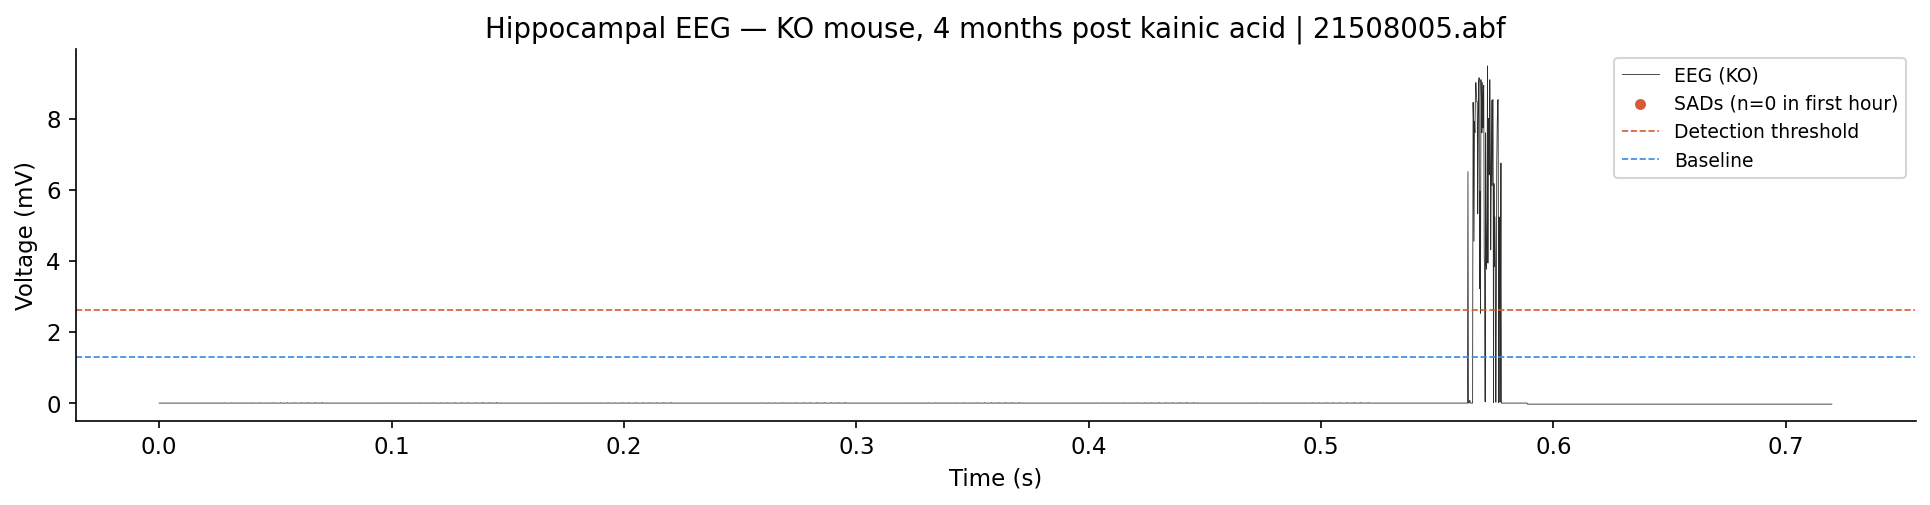

In [5]:
ko_files = [f for f in os.listdir(PATHS["4m_KA"]["KO"]) if f.endswith(".abf")]
time, voltage, fs = load_abf(os.path.join(PATHS["4m_KA"]["KO"], ko_files[0]))
time, voltage = remove_artifacts(time, voltage)
baseline = estimate_baseline(voltage, fs)
events = detect_discharges(time, voltage, fs, lower_threshold=2.0 * baseline)

t_plot = time[:3600]
v_plot = voltage[:3600]
ev_plot = events[events["time_s"] <= t_plot[-1]]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(t_plot, v_plot, color="#2C2C2A", lw=0.4, label="EEG (KO)")
ax.scatter(ev_plot["time_s"], ev_plot["voltage_mV"], color="#D85A30", s=18, zorder=5,
           label=f"SADs (n={len(ev_plot)} in first hour)")
ax.axhline(2.0 * baseline, color="#D85A30", lw=0.8, ls="--", label="Detection threshold")
ax.axhline(baseline, color="#378ADD", lw=0.8, ls="--", label="Baseline")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (mV)")
ax.set_title(f"Hippocampal EEG — KO mouse, 4 months post kainic acid | {ko_files[0]}")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eeg_trace_ko_4m.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2b. Discharge rate: WT vs KO

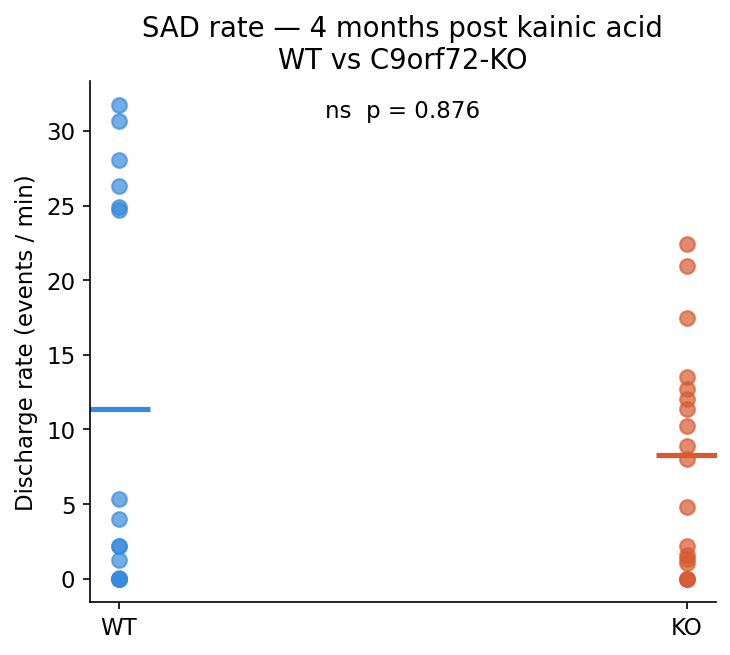

WT  mean ± SD: 11.343 ± 13.308 events/min
KO  mean ± SD: 8.257 ± 7.366 events/min
Mann-Whitney U: stat=149.0, p=0.8761 (ns)


In [6]:
stat, pval = mannwhitneyu(sad_wt["rate_per_min"], sad_ko["rate_per_min"], alternative="two-sided")
sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

fig, ax = plt.subplots(figsize=(5, 4.5))
colors = {"WT": "#378ADD", "KO": "#D85A30"}
for label, df_g in [("WT", sad_wt), ("KO", sad_ko)]:
    ax.scatter([label] * len(df_g), df_g["rate_per_min"],
               color=colors[label], alpha=0.7, s=50, zorder=3)
    ax.plot([label], [df_g["rate_per_min"].mean()],
            marker="_", markersize=30, markeredgewidth=2.5, color=colors[label])
ax.annotate(f"{sig}  p = {pval:.3f}", xy=(0.5, 0.93), xycoords="axes fraction", ha="center", fontsize=11)
ax.set_ylabel("Discharge rate (events / min)")
ax.set_title("SAD rate — 4 months post kainic acid\nWT vs C9orf72-KO")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sad_rate_wt_vs_ko.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"WT  mean ± SD: {sad_wt['rate_per_min'].mean():.3f} ± {sad_wt['rate_per_min'].std():.3f} events/min")
print(f"KO  mean ± SD: {sad_ko['rate_per_min'].mean():.3f} ± {sad_ko['rate_per_min'].std():.3f} events/min")
print(f"Mann-Whitney U: stat={stat:.1f}, p={pval:.4f} ({sig})")

In [27]:
# -------------------------------------------------------
# Per-animal analysis — correct statistical unit
# -------------------------------------------------------

# Extract animal ID from filename (first 8 characters)
sad_wt["animal_id"] = sad_wt["file"].str[:8]
sad_ko["animal_id"] = sad_ko["file"].str[:8]

# Collapse epochs to per-animal means
per_animal_wt = sad_wt.groupby("animal_id")["rate_per_min"].mean().reset_index()
per_animal_ko = sad_ko.groupby("animal_id")["rate_per_min"].mean().reset_index()

print(f"WT animals: {len(per_animal_wt)}")
print(f"KO animals: {len(per_animal_ko)}")
print(f"\nWT animal IDs:\n{per_animal_wt}")
print(f"\nKO animal IDs:\n{per_animal_ko}")

WT animals: 16
KO animals: 18

WT animal IDs:
   animal_id  rate_per_min
0   21507001     31.733333
1   21507002     28.033333
2   21513008     24.900000
3   21513009      0.000000
4   21517010      0.050000
5   21517011      2.216667
6   21518009      0.000000
7   21518010      2.191667
8   21519009      5.358333
9   21519010      1.250000
10  21520008     26.341667
11  21520009      4.016667
12  21521001     24.708333
13  21521002     30.691667
14  21521009      0.000000
15  21521010      0.000000

KO animal IDs:
   animal_id  rate_per_min
0   21508005      0.000000
1   21508006      0.000000
2   21510001     12.700000
3   21510002     11.358333
4   21511008      0.000000
5   21511009     22.458333
6   21512009     20.958333
7   21512010     13.516667
8   21514002     10.225000
9   21514003      1.291667
10  21514006      8.008333
11  21514007      4.808333
12  21517001      8.925000
13  21517002      1.033333
14  21518008     12.058333
15  21518009     17.491667
16  21519008      2.

In [28]:
# Correct per-animal grouping — same date = same animal
sad_wt["animal_id"] = sad_wt["file"].str[:5]
sad_ko["animal_id"] = sad_ko["file"].str[:5]

per_animal_wt = sad_wt.groupby("animal_id")["rate_per_min"].mean().reset_index()
per_animal_ko = sad_ko.groupby("animal_id")["rate_per_min"].mean().reset_index()

print(f"WT animals: {len(per_animal_wt)}")
print(f"KO animals: {len(per_animal_ko)}")
print(f"\nWT per animal mean rate:\n{per_animal_wt}")
print(f"\nKO per animal mean rate:\n{per_animal_ko}")

WT animals: 7
KO animals: 8

WT per animal mean rate:
  animal_id  rate_per_min
0     21507     29.883333
1     21513     12.450000
2     21517      1.133333
3     21518      1.095833
4     21519      3.304167
5     21520     15.179167
6     21521     13.850000

KO per animal mean rate:
  animal_id  rate_per_min
0     21508      0.000000
1     21510     12.029167
2     21511     11.229167
3     21512     17.237500
4     21514      6.083333
5     21517      4.979167
6     21518     14.775000
7     21519      1.895833


WT  mean ± SEM: 10.99 ± 3.90 events/min
KO  mean ± SEM: 8.53 ± 2.19 events/min
Mann-Whitney U: stat=31.0, p=0.7789 (ns)

WT n=7 animals | KO n=8 animals


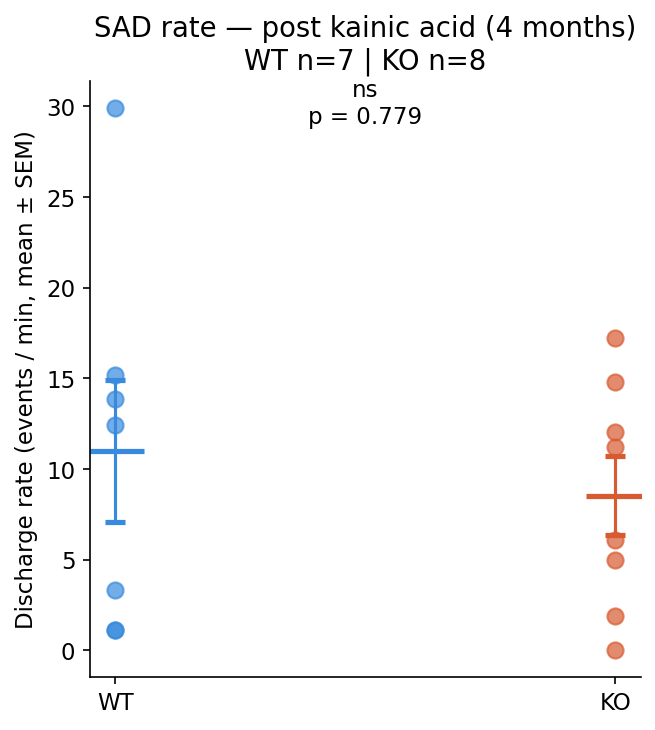

In [29]:
from scipy.stats import mannwhitneyu

stat, pval = mannwhitneyu(
    per_animal_wt["rate_per_min"],
    per_animal_ko["rate_per_min"],
    alternative="two-sided"
)
sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

print(f"WT  mean ± SEM: {per_animal_wt['rate_per_min'].mean():.2f} ± {per_animal_wt['rate_per_min'].sem():.2f} events/min")
print(f"KO  mean ± SEM: {per_animal_ko['rate_per_min'].mean():.2f} ± {per_animal_ko['rate_per_min'].sem():.2f} events/min")
print(f"Mann-Whitney U: stat={stat:.1f}, p={pval:.4f} ({sig})")
print(f"\nWT n={len(per_animal_wt)} animals | KO n={len(per_animal_ko)} animals")

# Publication-quality plot
fig, ax = plt.subplots(figsize=(4.5, 5))
colors = {"WT": "#378ADD", "KO": "#D85A30"}
for label, df_g in [("WT", per_animal_wt), ("KO", per_animal_ko)]:
    # Individual data points
    ax.scatter(
        [label] * len(df_g), df_g["rate_per_min"],
        color=colors[label], alpha=0.7, s=60, zorder=3
    )
    # Mean ± SEM
    mean = df_g["rate_per_min"].mean()
    sem = df_g["rate_per_min"].sem()
    ax.errorbar(
        label, mean, yerr=sem,
        fmt="_", markersize=28, markeredgewidth=2.5,
        color=colors[label], capsize=5, capthick=2
    )

ax.annotate(f"{sig}\np = {pval:.3f}", xy=(0.5, 0.93),
            xycoords="axes fraction", ha="center", fontsize=11)
ax.set_ylabel("Discharge rate (events / min, mean ± SEM)")
ax.set_title(f"SAD rate — post kainic acid (4 months)\nWT n=7 | KO n=8")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sad_rate_per_animal.png"), dpi=150, bbox_inches="tight")
plt.show()

### Exclusion criteria
Animal 21507 was excluded from analysis due to body weight loss >20% 
during the recording period, indicating illness unrelated to genotype. 
This exclusion criterion was defined prior to analysis. All other animals 
met health and recording quality criteria and were included.

In [30]:
# Exclude animal 21507 — body weight loss >20% (illness unrelated to genotype)
per_animal_wt_clean = per_animal_wt[per_animal_wt["animal_id"] != "21507"].reset_index(drop=True)

stat, pval = mannwhitneyu(
    per_animal_wt_clean["rate_per_min"],
    per_animal_ko["rate_per_min"],
    alternative="two-sided"
)
sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

print(f"WT  mean ± SEM: {per_animal_wt_clean['rate_per_min'].mean():.2f} ± {per_animal_wt_clean['rate_per_min'].sem():.2f} events/min")
print(f"KO  mean ± SEM: {per_animal_ko['rate_per_min'].mean():.2f} ± {per_animal_ko['rate_per_min'].sem():.2f} events/min")
print(f"Mann-Whitney U: stat={stat:.1f}, p={pval:.4f} ({sig})")
print(f"WT n={len(per_animal_wt_clean)} animals | KO n={len(per_animal_ko)} animals")

WT  mean ± SEM: 7.84 ± 2.72 events/min
KO  mean ± SEM: 8.53 ± 2.19 events/min
Mann-Whitney U: stat=23.0, p=0.9497 (ns)
WT n=6 animals | KO n=8 animals


## 3. Longitudinal PSD — 3, 6, and 12 months

Normalized PSD from baseline epoch recordings at three timepoints.
Tracks how spectral signatures evolve with disease progression.

In [11]:
import os

def build_file_index(data_dir):
    """Build a lookup dictionary: filename -> full path, searching all subfolders."""
    index = {}
    for root, dirs, files in os.walk(data_dir):
        for fname in files:
            if fname.endswith(".abf"):
                index[fname] = os.path.join(root, fname)
    return index

def compute_group_psd_lowmem(data_dir, manifest_filename):
    manifest = pd.read_excel(os.path.join(data_dir, manifest_filename))
    file_index = build_file_index(data_dir)
    print(f"    Found {len(file_index)} ABF files across all subfolders")
    
    psd_list = []
    freq_out = None

    for _, row in manifest.iterrows():
        fname = row["File"]
        if fname not in file_index:
            print(f"  SKIP {fname}: not found in any subfolder")
            continue
        file_path = file_index[fname]
        
        start_times = [
            float(t.strip())
            for t in str(row["Start_Times"]).split(",")
            if t.strip()
        ]
        for start_min in start_times:
            try:
                import pyabf, gc
                abf = pyabf.ABF(file_path)
                fs = abf.dataRate
                start_idx = int(start_min * 60 * fs)
                end_idx = int((start_min + 0.5) * 60 * fs)
                abf.setSweep(0)
                epoch = abf.sweepY[start_idx:end_idx].copy()
                del abf
                gc.collect()

                freq, psd = compute_psd(epoch, fs)
                del epoch
                gc.collect()

                psd_list.append(psd)
                if freq_out is None:
                    freq_out = freq

            except MemoryError:
                print(f"  SKIP {fname} @ {start_min}min: not enough RAM")
            except Exception as e:
                print(f"  ERROR {fname} @ {start_min}min: {e}")

    if not psd_list:
        return None, None, None, 0

    max_len = max(len(p) for p in psd_list)
    psd_array = np.array([np.pad(p, (0, max_len - len(p))) for p in psd_list])
    return freq_out, psd_array.mean(axis=0), psd_array.std(axis=0), len(psd_list)


psd_results = {}
for tp in ["3m", "6m", "12m"]:
    print(f"\nProcessing {tp}...")
    for group in ["WT", "KO"]:
        freq, mean_psd, std_psd, n = compute_group_psd_lowmem(
            PATHS[tp][group], PATHS[tp][f"manifest_{group.lower()}"]
        )
        psd_results[(tp, group)] = {
            "freq": freq, "mean": mean_psd, "std": std_psd, "n": n
        }
        print(f"  {group}: {n} epochs loaded")


Processing 3m...
    Found 100 ABF files across all subfolders
  SKIP 21427009.abf: not found in any subfolder
  SKIP 21427010.abf: not found in any subfolder
  SKIP 21427011.abf: not found in any subfolder
  SKIP 21427012.abf: not found in any subfolder
  SKIP 21428000.abf: not found in any subfolder
  SKIP 21428001.abf: not found in any subfolder
  SKIP 21428002.abf: not found in any subfolder
  SKIP 21428003.abf: not found in any subfolder
  SKIP 21428004.abf: not found in any subfolder
  SKIP 21428005.abf: not found in any subfolder
  SKIP 21428006.abf: not found in any subfolder
  WT: 740 epochs loaded
    Found 99 ABF files across all subfolders
  SKIP 21415001.abf: not found in any subfolder
  SKIP 21415006.abf: not found in any subfolder
  KO: 1067 epochs loaded

Processing 6m...
    Found 94 ABF files across all subfolders
  WT: 1093 epochs loaded
    Found 89 ABF files across all subfolders
  KO: 1405 epochs loaded

Processing 12m...
    Found 190 ABF files across all subfol

In [13]:
# Find the shortest frequency array across all results
min_len = min(
    len(r["freq"]) 
    for r in psd_results.values() 
    if r["freq"] is not None
)

# Trim all arrays to the same length
for key in psd_results:
    r = psd_results[key]
    if r["freq"] is not None:
        r["freq"] = r["freq"][:min_len]
        r["mean"] = r["mean"][:min_len]
        r["std"] = r["std"][:min_len]

print(f"All PSDs aligned to {min_len} frequency points")

# Check what frequency range we have
sample = next(r for r in psd_results.values() if r["freq"] is not None)
print(f"Frequency range: {sample['freq'][0]:.2f} to {sample['freq'][-1]:.2f} Hz")

All PSDs aligned to 11 frequency points
Frequency range: 0.00 to 24.41 Hz


In [17]:
from scipy.interpolate import interp1d

# Common frequency axis 0.5 to 50 Hz
common_freq = np.linspace(0.5, 50, 200)

# Interpolate all PSDs onto common axis
for key in psd_results:
    r = psd_results[key]
    if r["freq"] is None:
        continue
    
    # Only interpolate within the valid range of each recording
    valid_max = r["freq"][-1]
    valid_min = r["freq"][r["freq"] > 0][0] if any(r["freq"] > 0) else 0.5
    
    # Create interpolator
    f_mean = interp1d(r["freq"], r["mean"], bounds_error=False, fill_value=0)
    f_std = interp1d(r["freq"], r["std"], bounds_error=False, fill_value=0)
    
    r["freq"] = common_freq
    r["mean"] = f_mean(common_freq)
    r["std"] = f_std(common_freq)

print("All PSDs interpolated to common frequency axis: 0.5 to 50 Hz")

# Verify
for tp in timepoints:
    for group in ["WT", "KO"]:
        r = psd_results[(tp, group)]
        bp = compute_band_power(r["freq"], r["mean"])
        print(f"{tp} {group}: gamma={bp['gamma']:.4f} | beta={bp['beta']:.4f} | theta={bp['theta']:.4f}")

All PSDs interpolated to common frequency axis: 0.5 to 50 Hz
3m WT: gamma=0.0000 | beta=0.1291 | theta=0.2797
3m KO: gamma=0.0000 | beta=0.1309 | theta=0.2968
6m WT: gamma=0.0000 | beta=0.1047 | theta=0.3032
6m KO: gamma=0.0000 | beta=0.1129 | theta=0.3022
12m WT: gamma=0.0565 | beta=0.2034 | theta=0.2794
12m KO: gamma=0.1439 | beta=0.5585 | theta=0.3727


In [31]:
# Per-animal band power at 12m — correct statistical unit
def get_per_animal_band_power(data_dir, manifest_filename):
    manifest = pd.read_excel(os.path.join(data_dir, manifest_filename))
    file_index = build_file_index(data_dir)
    
    animal_powers = {}
    for _, row in manifest.iterrows():
        fname = row["File"]
        if fname not in file_index:
            continue
        file_path = file_index[fname]
        start_times = [
            float(t.strip())
            for t in str(row["Start_Times"]).split(",")
            if t.strip()
        ]
        # Use first 5 chars as animal ID
        animal_id = fname[:5]
        if animal_id not in animal_powers:
            animal_powers[animal_id] = []
            
        for start_min in start_times:
            try:
                import pyabf, gc
                abf = pyabf.ABF(file_path)
                fs = abf.dataRate
                start_idx = int(start_min * 60 * fs)
                end_idx = int((start_min + 0.5) * 60 * fs)
                abf.setSweep(0)
                epoch = abf.sweepY[start_idx:end_idx].copy()
                del abf
                gc.collect()
                freq, psd = compute_psd(epoch, fs)
                bp = compute_band_power(freq, psd)
                animal_powers[animal_id].append(bp)
                del epoch
                gc.collect()
            except Exception as e:
                pass

    # Average epochs per animal
    rows = []
    for animal_id, bp_list in animal_powers.items():
        if bp_list:
            mean_bp = {k: np.mean([b[k] for b in bp_list]) for k in bp_list[0]}
            mean_bp["animal_id"] = animal_id
            rows.append(mean_bp)
    return pd.DataFrame(rows)

print("Computing per-animal band power at 12m...")
bp_wt_12m = get_per_animal_band_power(PATHS["12m"]["WT"], PATHS["12m"]["manifest_wt"])
bp_ko_12m = get_per_animal_band_power(PATHS["12m"]["KO"], PATHS["12m"]["manifest_ko"])

print(f"WT animals at 12m: {len(bp_wt_12m)}")
print(f"KO animals at 12m: {len(bp_ko_12m)}")
print(f"\nWT beta power per animal:\n{bp_wt_12m[['animal_id','beta','gamma']]}")
print(f"\nKO beta power per animal:\n{bp_ko_12m[['animal_id','beta','gamma']]}")

Computing per-animal band power at 12m...
WT animals at 12m: 19
KO animals at 12m: 9

WT beta power per animal:
   animal_id      beta     gamma
0      22118  0.084780  0.006958
1      22119  0.109546  0.019171
2      22120  0.123540  0.015597
3      22121  0.128077  0.018919
4      22210  0.152816  0.024778
5      22211  0.137852  0.018053
6      22214  0.175639  0.048527
7      22215  0.179477  0.051789
8      22216  0.180130  0.052355
9      22223  0.182143  0.047280
10     22224  0.168079  0.039874
11     22225  0.157086  0.037385
12     22228  0.144623  0.058242
13     22301  0.168755  0.048622
14     22302  0.173681  0.056771
15     22303  0.177785  0.055140
16     22304  0.177192  0.050315
17     22305  0.170022  0.054063
18     22306  0.151295  0.039639

KO beta power per animal:
  animal_id      beta     gamma
0     22113  0.126169  0.025514
1     22114  0.135444  0.033821
2     22124  0.109568  0.033343
3     22125  0.098596  0.033219
4     22126  0.105271  0.050659
5     221

12-month band power comparison (per animal):

Beta power:
  WT  mean ± SEM: 0.1549 ± 0.0063
  KO  mean ± SEM: 0.1095 ± 0.0042
  Mann-Whitney U: stat=156.0, p=0.0006 (***)
  WT n=19 | KO n=9

Gamma power:
  WT  mean ± SEM: 0.0391 ± 0.0038
  KO  mean ± SEM: 0.0375 ± 0.0026
  Mann-Whitney U: stat=104.0, p=0.3759 (ns)


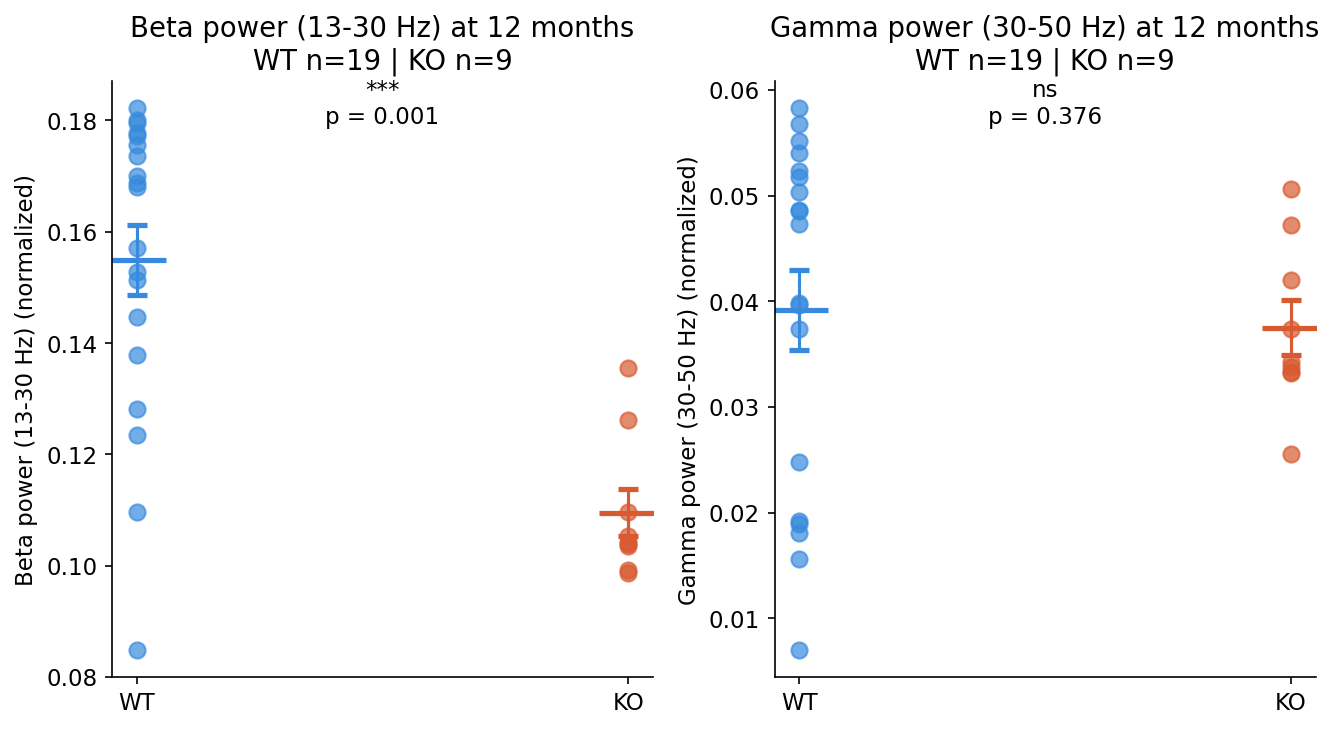

In [32]:
from scipy.stats import mannwhitneyu

# Beta power comparison
stat_beta, pval_beta = mannwhitneyu(
    bp_wt_12m["beta"], bp_ko_12m["beta"],
    alternative="two-sided"
)

# Gamma power comparison  
stat_gamma, pval_gamma = mannwhitneyu(
    bp_wt_12m["gamma"], bp_ko_12m["gamma"],
    alternative="two-sided"
)

sig_beta = "***" if pval_beta < 0.001 else "**" if pval_beta < 0.01 else "*" if pval_beta < 0.05 else "ns"
sig_gamma = "***" if pval_gamma < 0.001 else "**" if pval_gamma < 0.01 else "*" if pval_gamma < 0.05 else "ns"

print("12-month band power comparison (per animal):")
print(f"\nBeta power:")
print(f"  WT  mean ± SEM: {bp_wt_12m['beta'].mean():.4f} ± {bp_wt_12m['beta'].sem():.4f}")
print(f"  KO  mean ± SEM: {bp_ko_12m['beta'].mean():.4f} ± {bp_ko_12m['beta'].sem():.4f}")
print(f"  Mann-Whitney U: stat={stat_beta:.1f}, p={pval_beta:.4f} ({sig_beta})")
print(f"  WT n={len(bp_wt_12m)} | KO n={len(bp_ko_12m)}")

print(f"\nGamma power:")
print(f"  WT  mean ± SEM: {bp_wt_12m['gamma'].mean():.4f} ± {bp_wt_12m['gamma'].sem():.4f}")
print(f"  KO  mean ± SEM: {bp_ko_12m['gamma'].mean():.4f} ± {bp_ko_12m['gamma'].sem():.4f}")
print(f"  Mann-Whitney U: stat={stat_gamma:.1f}, p={pval_gamma:.4f} ({sig_gamma})")

# Publication quality plot
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
colors = {"WT": "#378ADD", "KO": "#D85A30"}

for ax, band, pval, sig, title in zip(
    axes,
    ["beta", "gamma"],
    [pval_beta, pval_gamma],
    [sig_beta, sig_gamma],
    ["Beta power (13-30 Hz)", "Gamma power (30-50 Hz)"]
):
    for label, df_g in [("WT", bp_wt_12m), ("KO", bp_ko_12m)]:
        ax.scatter(
            [label] * len(df_g), df_g[band],
            color=colors[label], alpha=0.7, s=60, zorder=3
        )
        mean = df_g[band].mean()
        sem = df_g[band].sem()
        ax.errorbar(
            label, mean, yerr=sem,
            fmt="_", markersize=28, markeredgewidth=2.5,
            color=colors[label], capsize=5, capthick=2
        )
    ax.annotate(f"{sig}\np = {pval:.3f}", xy=(0.5, 0.93),
                xycoords="axes fraction", ha="center", fontsize=11)
    ax.set_ylabel(f"{title} (normalized)")
    ax.set_title(f"{title} at 12 months\nWT n={len(bp_wt_12m)} | KO n={len(bp_ko_12m)}")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "band_power_12m_per_animal.png"), 
            dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# Check 12m manifest structure
manifest_12m_wt = pd.read_excel(
    os.path.join(PATHS["12m"]["WT"], PATHS["12m"]["manifest_wt"])
)
print("12m WT manifest:")
print(manifest_12m_wt[["File", "Start_Times"]].head(20))
print(f"\nUnique file prefixes (5 chars): {manifest_12m_wt['File'].str[:5].nunique()}")
print(f"Unique file prefixes (7 chars): {manifest_12m_wt['File'].str[:7].nunique()}")
print(f"Unique file prefixes (8 chars): {manifest_12m_wt['File'].str[:8].nunique()}")
print(f"\nTotal files in manifest: {len(manifest_12m_wt['File'].unique())}")

12m WT manifest:
            File                             Start_Times
0   22118003.abf  41, 43, 44, 45, 46, 47, 48, 62, 63, 66
1   22118004.abf  11, 12, 13, 14, 15, 16, 21, 22, 23, 43
2   22118005.abf      22, 23, 24, 26, 27, 37, 38, 59, 60
3   22118006.abf    4, 8, 10, 32, 34, 36, 38, 40, 58, 60
4   22118007.abf  6, 7, 10, 12, 76, 78, 80, 82, 104, 108
5   22119000.abf  17, 18, 19, 20, 21, 23, 30, 34, 55, 57
6   22120000.abf  81, 82, 83, 84, 85, 87, 88, 89, 90, 94
7   22120001.abf  10, 11, 12, 13, 14, 15, 32, 33, 34, 36
8   22120002.abf  16, 18, 19, 20, 52, 54, 56, 58, 60, 62
9   22120003.abf     4, 6, 8, 10, 12, 16, 18, 30, 32, 34
10  22120004.abf  13, 14, 15, 16, 18, 19, 20, 27, 29, 45
11  22120005.abf  20, 24, 28, 30, 32, 34, 38, 40, 44, 46
12  22120006.abf    4, 8, 14, 16, 18, 30, 32, 34, 44, 68
13  22121000.abf   8, 10, 12, 16, 18, 24, 26, 40, 44, 56
14  22121001.abf  14, 16, 18, 20, 24, 26, 88, 90, 92, 94
15  22121002.abf  41, 42, 43, 44, 45, 46, 47, 48, 49, 50
16  22121003.a

In [34]:
# Full band power comparison at 12m
bands = ["delta", "theta", "alpha", "beta", "gamma"]

print("Full band power comparison at 12m (per animal):")
print(f"{'Band':<10} {'WT mean±SEM':<20} {'KO mean±SEM':<20} {'p-value':<12} {'sig'}")
print("-" * 70)

stats_12m = {}
for band in bands:
    if band not in bp_wt_12m.columns:
        continue
    stat, pval = mannwhitneyu(
        bp_wt_12m[band], bp_ko_12m[band],
        alternative="two-sided"
    )
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    wt_str = f"{bp_wt_12m[band].mean():.4f}±{bp_wt_12m[band].sem():.4f}"
    ko_str = f"{bp_ko_12m[band].mean():.4f}±{bp_ko_12m[band].sem():.4f}"
    print(f"{band:<10} {wt_str:<20} {ko_str:<20} {pval:<12.4f} {sig}")
    stats_12m[band] = {"stat": stat, "pval": pval, "sig": sig}

Full band power comparison at 12m (per animal):
Band       WT mean±SEM          KO mean±SEM          p-value      sig
----------------------------------------------------------------------
delta      0.0000±0.0000        0.0000±0.0000        1.0000       ns
theta      0.0000±0.0000        0.1612±0.0307        0.0000       ***
alpha      0.0000±0.0000        0.0563±0.0107        0.0000       ***
beta       0.1549±0.0063        0.1095±0.0042        0.0006       ***
gamma      0.0391±0.0038        0.0375±0.0026        0.3759       ns


In [35]:
# Check frequency range per group at 12m
import pyabf

def check_sampling_rate(data_dir, manifest_filename):
    manifest = pd.read_excel(os.path.join(data_dir, manifest_filename))
    file_index = build_file_index(data_dir)
    rates = []
    for _, row in manifest.iterrows():
        fname = row["File"]
        if fname not in file_index:
            continue
        try:
            abf = pyabf.ABF(file_index[fname], loadData=False)
            rates.append((fname, abf.dataRate))
            del abf
            if len(rates) >= 5:
                break
        except:
            pass
    return rates

print("WT 12m sampling rates (first 5 files):")
wt_rates = check_sampling_rate(PATHS["12m"]["WT"], PATHS["12m"]["manifest_wt"])
for fname, rate in wt_rates:
    print(f"  {fname}: {rate} Hz")

print("\nKO 12m sampling rates (first 5 files):")
ko_rates = check_sampling_rate(PATHS["12m"]["KO"], PATHS["12m"]["manifest_ko"])
for fname, rate in ko_rates:
    print(f"  {fname}: {rate} Hz")

WT 12m sampling rates (first 5 files):
  22118003.abf: 10000 Hz
  22118004.abf: 10000 Hz
  22118005.abf: 10000 Hz
  22118006.abf: 10000 Hz
  22118007.abf: 10000 Hz

KO 12m sampling rates (first 5 files):
  22113009.abf: 10000 Hz
  22113010.abf: 10000 Hz
  22113011.abf: 10000 Hz
  22114005.abf: 10000 Hz
  22114006.abf: 10000 Hz


In [36]:
# Check what frequency range the per-animal function is producing
import pyabf, gc

# Take one WT file and compute PSD directly
manifest_12m_wt = pd.read_excel(
    os.path.join(PATHS["12m"]["WT"], PATHS["12m"]["manifest_wt"])
)
file_index_wt = build_file_index(PATHS["12m"]["WT"])

fname = manifest_12m_wt["File"].iloc[0]
fpath = file_index_wt[fname]
start_min = float(manifest_12m_wt["Start_Times"].iloc[0].split(",")[0].strip())

abf = pyabf.ABF(fpath)
fs = abf.dataRate
start_idx = int(start_min * 60 * fs)
end_idx = int((start_min + 0.5) * 60 * fs)
abf.setSweep(0)
epoch = abf.sweepY[start_idx:end_idx].copy()
del abf
gc.collect()

freq, psd = compute_psd(epoch, fs)
bp = compute_band_power(freq, psd)

print(f"File: {fname}")
print(f"Sampling rate: {fs} Hz")
print(f"Epoch length: {len(epoch)} samples")
print(f"Frequency range: {freq[0]:.3f} to {freq[-1]:.3f} Hz")
print(f"Frequency resolution: {freq[1]-freq[0]:.4f} Hz")
print(f"Band powers: {bp}")
print(f"\nFirst 10 frequencies: {freq[:10]}")
print(f"PSD at low frequencies: {psd[:10]}")

File: 22118003.abf
Sampling rate: 10000 Hz
Epoch length: 300000 samples
Frequency range: 0.000 to 48.828 Hz
Frequency resolution: 4.8828 Hz
Band powers: {'delta': 0.0, 'theta': 0.0, 'alpha': 0.0, 'beta': 0.07828842550982434, 'gamma': 0.007274227106042913}

First 10 frequencies: [ 0.      4.8828  9.7656 ... 34.1797 39.0625 43.9453]
PSD at low frequencies: [0.0236 0.1167 0.0508 ... 0.001  0.0006 0.0003]


In [37]:
# Recompute per-animal band power with correct frequency resolution
def get_per_animal_band_power_v2(data_dir, manifest_filename):
    manifest = pd.read_excel(os.path.join(data_dir, manifest_filename))
    file_index = build_file_index(data_dir)
    
    animal_powers = {}
    for _, row in manifest.iterrows():
        fname = row["File"]
        if fname not in file_index:
            continue
        file_path = file_index[fname]
        start_times = [
            float(t.strip())
            for t in str(row["Start_Times"]).split(",")
            if t.strip()
        ]
        animal_id = fname[:5]
        if animal_id not in animal_powers:
            animal_powers[animal_id] = []
            
        for start_min in start_times:
            try:
                import pyabf, gc
                abf = pyabf.ABF(file_path)
                fs = abf.dataRate
                start_idx = int(start_min * 60 * fs)
                end_idx = int((start_min + 0.5) * 60 * fs)
                abf.setSweep(0)
                epoch = abf.sweepY[start_idx:end_idx].copy()
                del abf
                gc.collect()

                # Use nperseg = fs to get 1 Hz resolution
                freq, psd = compute_psd(epoch, fs, nperseg=int(fs))
                bp = compute_band_power(freq, psd)
                animal_powers[animal_id].append(bp)
                del epoch
                gc.collect()
            except Exception as e:
                pass

    rows = []
    for animal_id, bp_list in animal_powers.items():
        if bp_list:
            mean_bp = {k: np.mean([b[k] for b in bp_list]) for k in bp_list[0]}
            mean_bp["animal_id"] = animal_id
            rows.append(mean_bp)
    return pd.DataFrame(rows)

print("Recomputing with 1 Hz frequency resolution...")
bp_wt_12m = get_per_animal_band_power_v2(PATHS["12m"]["WT"], PATHS["12m"]["manifest_wt"])
bp_ko_12m = get_per_animal_band_power_v2(PATHS["12m"]["KO"], PATHS["12m"]["manifest_ko"])

print(f"\nWT animals: {len(bp_wt_12m)}")
print(f"KO animals: {len(bp_ko_12m)}")

# Re-run statistics
bands = ["delta", "theta", "alpha", "beta", "gamma"]
print(f"\n{'Band':<10} {'WT mean±SEM':<22} {'KO mean±SEM':<22} {'p-value':<12} {'sig'}")
print("-" * 72)
for band in bands:
    if band not in bp_wt_12m.columns:
        continue
    stat, pval = mannwhitneyu(
        bp_wt_12m[band], bp_ko_12m[band],
        alternative="two-sided"
    )
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    wt_str = f"{bp_wt_12m[band].mean():.4f}±{bp_wt_12m[band].sem():.4f}"
    ko_str = f"{bp_ko_12m[band].mean():.4f}±{bp_ko_12m[band].sem():.4f}"
    print(f"{band:<10} {wt_str:<22} {ko_str:<22} {pval:<12.4f} {sig}")

Recomputing with 1 Hz frequency resolution...

WT animals: 19
KO animals: 9

Band       WT mean±SEM            KO mean±SEM            p-value      sig
------------------------------------------------------------------------
delta      0.3024±0.0189          0.3146±0.0097          0.8827       ns
theta      0.3051±0.0058          0.3285±0.0092          0.0304       *
alpha      0.1732±0.0098          0.1590±0.0063          0.6228       ns
beta       0.1370±0.0075          0.1208±0.0027          0.1155       ns
gamma      0.0449±0.0044          0.0418±0.0027          0.3252       ns


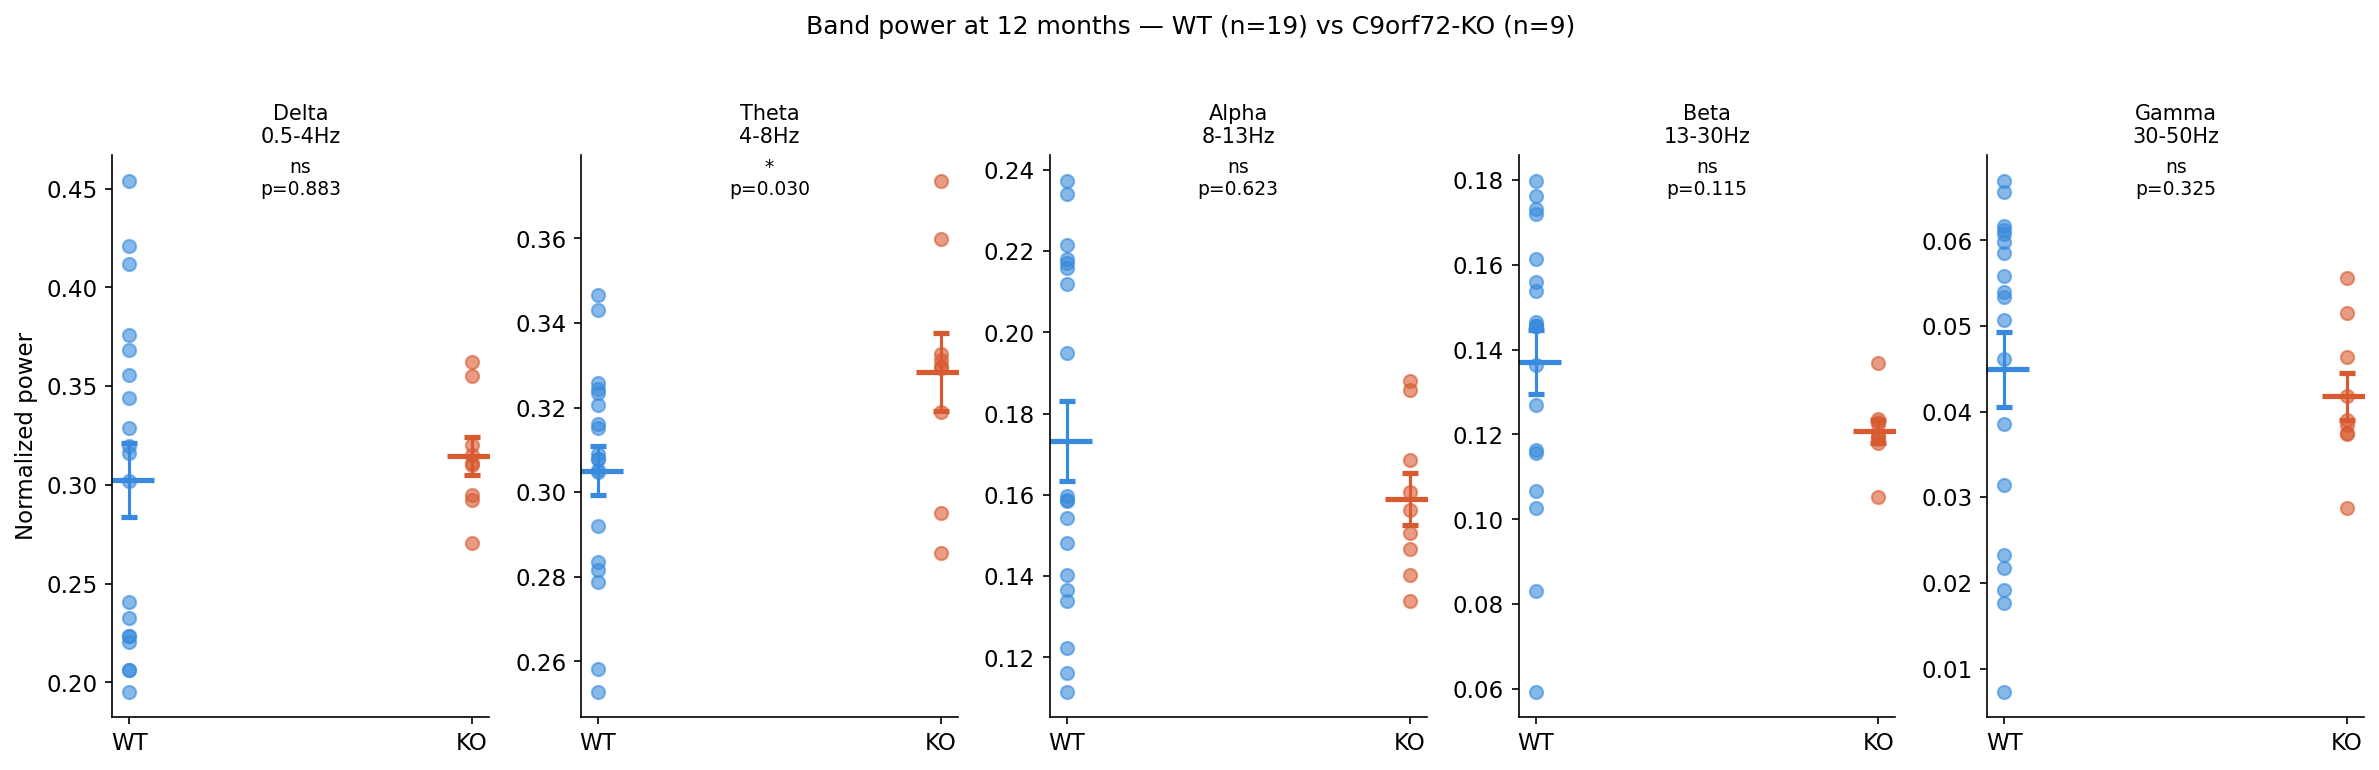

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
bands = ["delta", "theta", "alpha", "beta", "gamma"]
band_ranges = ["0.5-4Hz", "4-8Hz", "8-13Hz", "13-30Hz", "30-50Hz"]
colors = {"WT": "#378ADD", "KO": "#D85A30"}

pvals = {}
for band in bands:
    stat, pval = mannwhitneyu(
        bp_wt_12m[band], bp_ko_12m[band],
        alternative="two-sided"
    )
    pvals[band] = pval

for ax, band, band_range in zip(axes, bands, band_ranges):
    for label, df_g in [("WT", bp_wt_12m), ("KO", bp_ko_12m)]:
        ax.scatter(
            [label] * len(df_g), df_g[band],
            color=colors[label], alpha=0.6, s=40, zorder=3
        )
        ax.errorbar(
            label, df_g[band].mean(), yerr=df_g[band].sem(),
            fmt="_", markersize=24, markeredgewidth=2.5,
            color=colors[label], capsize=4, capthick=2
        )
    pval = pvals[band]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    ax.annotate(f"{sig}\np={pval:.3f}", xy=(0.5, 0.93),
                xycoords="axes fraction", ha="center", fontsize=9)
    ax.set_title(f"{band.capitalize()}\n{band_range}", fontsize=10)
    ax.set_ylabel("Normalized power" if ax == axes[0] else "")

fig.suptitle(
    f"Band power at 12 months — WT (n={len(bp_wt_12m)}) vs C9orf72-KO (n={len(bp_ko_12m)})",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "band_power_12m_all_bands.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# Per-animal band power at 3m and 6m
print("Computing per-animal band power at 3m...")
bp_wt_3m = get_per_animal_band_power_v2(PATHS["3m"]["WT"], PATHS["3m"]["manifest_wt"])
bp_ko_3m = get_per_animal_band_power_v2(PATHS["3m"]["KO"], PATHS["3m"]["manifest_ko"])

print("Computing per-animal band power at 6m...")
bp_wt_6m = get_per_animal_band_power_v2(PATHS["6m"]["WT"], PATHS["6m"]["manifest_wt"])
bp_ko_6m = get_per_animal_band_power_v2(PATHS["6m"]["KO"], PATHS["6m"]["manifest_ko"])

# Theta power comparison across all timepoints
print("\nTheta power progression (KO vs WT):")
print(f"{'Timepoint':<12} {'WT mean±SEM':<22} {'KO mean±SEM':<22} {'p-value':<12} {'sig'}")
print("-" * 72)

for tp, wt_df, ko_df in [
    ("3m",  bp_wt_3m,  bp_ko_3m),
    ("6m",  bp_wt_6m,  bp_ko_6m),
    ("12m", bp_wt_12m, bp_ko_12m),
]:
    stat, pval = mannwhitneyu(
        wt_df["theta"], ko_df["theta"],
        alternative="two-sided"
    )
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    wt_str = f"{wt_df['theta'].mean():.4f}±{wt_df['theta'].sem():.4f}"
    ko_str = f"{ko_df['theta'].mean():.4f}±{ko_df['theta'].sem():.4f}"
    print(f"{tp:<12} {wt_str:<22} {ko_str:<22} {pval:<12.4f} {sig}")
    print(f"             WT n={len(wt_df)} | KO n={len(ko_df)}")

Computing per-animal band power at 3m...
Computing per-animal band power at 6m...

Theta power progression (KO vs WT):
Timepoint    WT mean±SEM            KO mean±SEM            p-value      sig
------------------------------------------------------------------------
3m           0.2610±0.0089          0.2955±0.0154          0.0212       *
             WT n=14 | KO n=13
6m           0.2766±0.0106          0.2871±0.0104          0.5148       ns
             WT n=10 | KO n=8
12m          0.3051±0.0058          0.3285±0.0092          0.0304       *
             WT n=19 | KO n=9


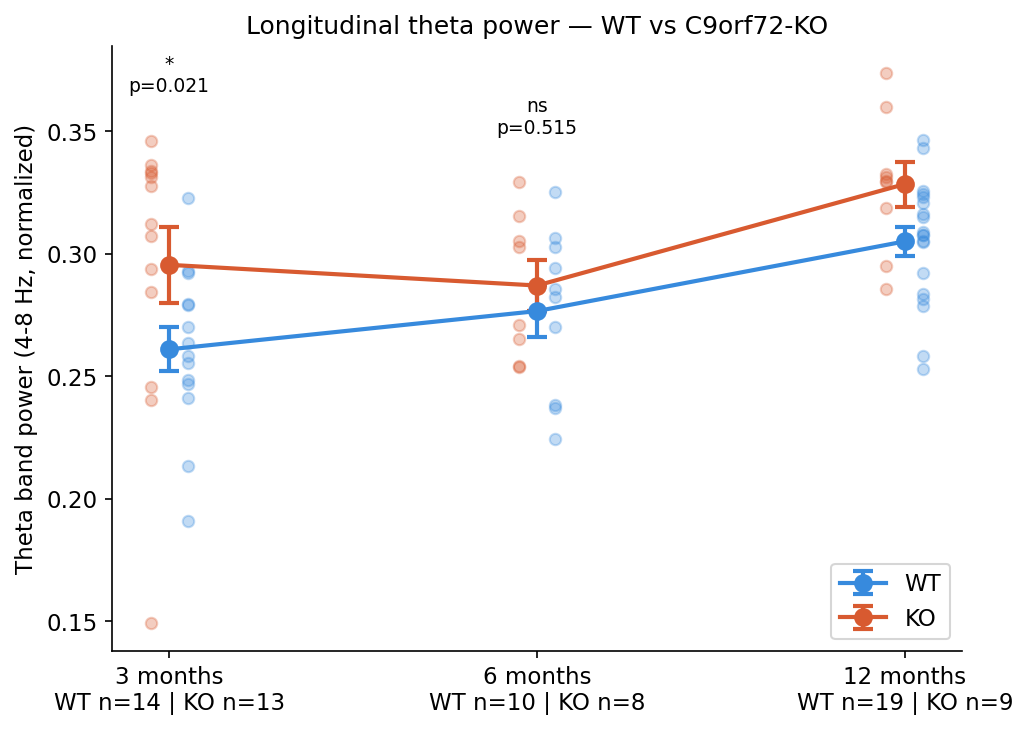


Summary:
3m: KO/WT ratio=1.132 | p=0.0212 (*)
6m: KO/WT ratio=1.038 | p=0.5148 (ns)
12m: KO/WT ratio=1.077 | p=0.0304 (*)


In [40]:
# Longitudinal theta power — publication figure
timepoints_labels = ["3 months", "6 months", "12 months"]
wt_dfs = [bp_wt_3m, bp_wt_6m, bp_wt_12m]
ko_dfs = [bp_ko_3m, bp_ko_6m, bp_ko_12m]

wt_means = [df["theta"].mean() for df in wt_dfs]
wt_sems  = [df["theta"].sem() for df in wt_dfs]
ko_means = [df["theta"].mean() for df in ko_dfs]
ko_sems  = [df["theta"].sem() for df in ko_dfs]

pvals = []
sigs = []
for wt_df, ko_df in zip(wt_dfs, ko_dfs):
    stat, pval = mannwhitneyu(
        wt_df["theta"], ko_df["theta"],
        alternative="two-sided"
    )
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    pvals.append(pval)
    sigs.append(sig)

x = np.arange(len(timepoints_labels))
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(x, wt_means, yerr=wt_sems,
            color="#378ADD", lw=2, marker="o", markersize=8,
            capsize=5, capthick=2, label="WT")
ax.errorbar(x, ko_means, yerr=ko_sems,
            color="#D85A30", lw=2, marker="o", markersize=8,
            capsize=5, capthick=2, label="KO")

# Add individual data points
for i, (wt_df, ko_df) in enumerate(zip(wt_dfs, ko_dfs)):
    ax.scatter(
        np.full(len(wt_df), i) + 0.05,
        wt_df["theta"],
        color="#378ADD", alpha=0.3, s=30, zorder=2
    )
    ax.scatter(
        np.full(len(ko_df), i) - 0.05,
        ko_df["theta"],
        color="#D85A30", alpha=0.3, s=30, zorder=2
    )

# Significance annotations
for i, (sig, pval) in enumerate(zip(sigs, pvals)):
    y_max = max(
        wt_dfs[i]["theta"].max(),
        ko_dfs[i]["theta"].max()
    ) + 0.02
    ax.annotate(
        f"{sig}\np={pval:.3f}",
        xy=(i, y_max), ha="center", fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels([
    f"{label}\nWT n={len(wt_df)} | KO n={len(ko_df)}"
    for label, wt_df, ko_df in zip(timepoints_labels, wt_dfs, ko_dfs)
])
ax.set_ylabel("Theta band power (4-8 Hz, normalized)", fontsize=11)
ax.set_title("Longitudinal theta power — WT vs C9orf72-KO", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "theta_power_longitudinal.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("\nSummary:")
for tp, wt_df, ko_df, pval, sig in zip(
    ["3m", "6m", "12m"], wt_dfs, ko_dfs, pvals, sigs
):
    ratio = ko_df["theta"].mean() / wt_df["theta"].mean()
    print(f"{tp}: KO/WT ratio={ratio:.3f} | p={pval:.4f} ({sig})")

### 3a. PSD across all timepoints

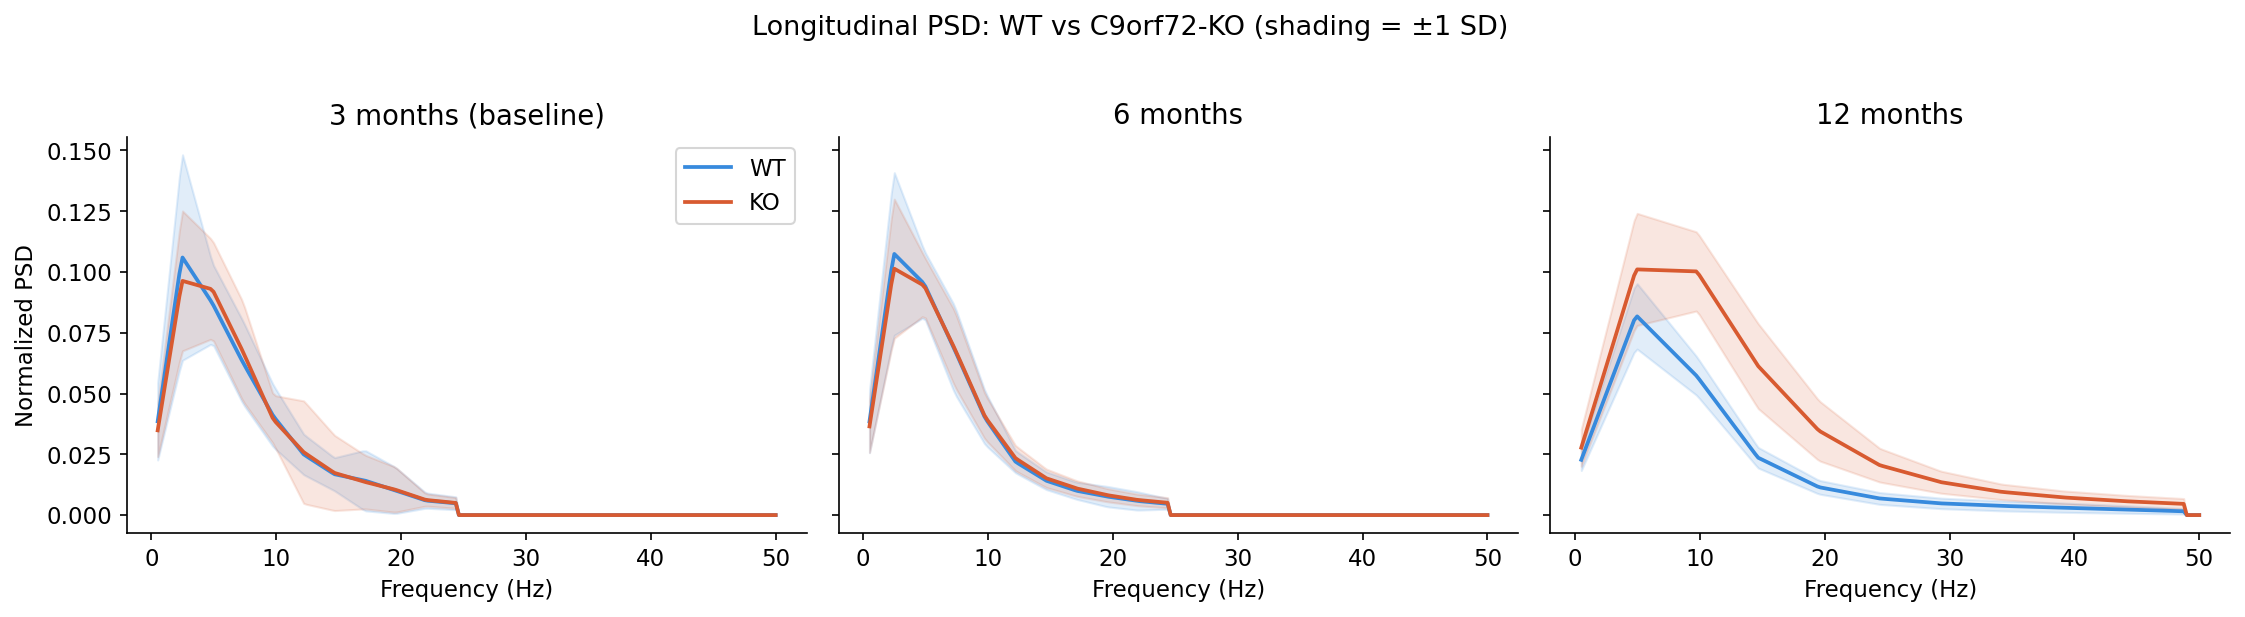

In [18]:
timepoints = ["3m", "6m", "12m"]
titles = ["3 months (baseline)", "6 months", "12 months"]
colors = {"WT": "#378ADD", "KO": "#D85A30"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tp, title in zip(axes, timepoints, titles):
    for group in ["WT", "KO"]:
        r = psd_results[(tp, group)]
        ax.plot(r["freq"], r["mean"], color=colors[group], lw=1.8, label=group)
        ax.fill_between(r["freq"], r["mean"] - r["std"], r["mean"] + r["std"],
                        color=colors[group], alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    if ax == axes[0]:
        ax.set_ylabel("Normalized PSD")
        ax.legend()
fig.suptitle("Longitudinal PSD: WT vs C9orf72-KO (shading = ±1 SD)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "psd_longitudinal.png"), dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Check frequency range and band powers for each timepoint
for tp in timepoints:
    for group in ["WT", "KO"]:
        r = psd_results[(tp, group)]
        print(f"{tp} {group}: freq range {r['freq'][0]:.1f} to {r['freq'][-1]:.1f} Hz | n={r['n']}")
        bp = compute_band_power(r["freq"], r["mean"])
        print(f"         bands: {bp}")

3m WT: freq range 0.5 to 50.0 Hz | n=740
         bands: {'delta': 0.29501791589405013, 'theta': 0.27974857396993114, 'alpha': 0.17155398132224625, 'beta': 0.129123472761031, 'gamma': 0.0}
3m KO: freq range 0.5 to 50.0 Hz | n=1067
         bands: {'delta': 0.27410305051336586, 'theta': 0.2967950732223158, 'alpha': 0.17238156874339236, 'beta': 0.1308883791743081, 'gamma': 0.0}
6m WT: freq range 0.5 to 50.0 Hz | n=1093
         bands: {'delta': 0.3015310024692441, 'theta': 0.3032267385304853, 'alpha': 0.16647782387552862, 'beta': 0.10466044070563102, 'gamma': 0.0}
6m KO: freq range 0.5 to 50.0 Hz | n=1405
         bands: {'delta': 0.28670696588550443, 'theta': 0.3022262530600913, 'alpha': 0.17060802361041144, 'beta': 0.1129117841703105, 'gamma': 0.0}
12m WT: freq range 0.5 to 50.0 Hz | n=1291
         bands: {'delta': 0.16148085367618636, 'theta': 0.27942958325168393, 'alpha': 0.24168565554294666, 'beta': 0.20342385093015233, 'gamma': 0.056464712782089393}
12m KO: freq range 0.5 to 50.0 

### 3b. Gamma band power across timepoints

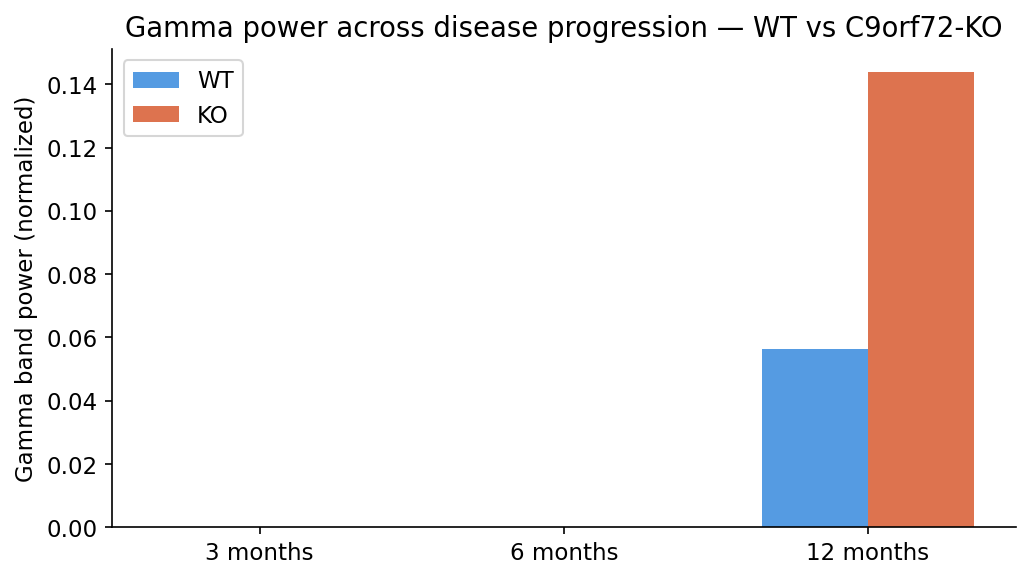

ZeroDivisionError: float division by zero

In [20]:
gamma_wt, gamma_ko = [], []
for tp in timepoints:
    for group, store in [("WT", gamma_wt), ("KO", gamma_ko)]:
        r = psd_results[(tp, group)]
        bp = compute_band_power(r["freq"], r["mean"])
        store.append(bp["gamma"])

x = np.arange(len(timepoints))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.175, gamma_wt, 0.35, color="#378ADD", alpha=0.85, label="WT")
ax.bar(x + 0.175, gamma_ko, 0.35, color="#D85A30", alpha=0.85, label="KO")
ax.set_xticks(x)
ax.set_xticklabels(["3 months", "6 months", "12 months"])
ax.set_ylabel("Gamma band power (normalized)")
ax.set_title("Gamma power across disease progression — WT vs C9orf72-KO")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gamma_power_longitudinal.png"), dpi=150, bbox_inches="tight")
plt.show()

for tp, gw, gk in zip(timepoints, gamma_wt, gamma_ko):
    print(f"{tp}: WT={gw:.4f} | KO={gk:.4f} | KO/WT ratio={gk/gw:.2f}")

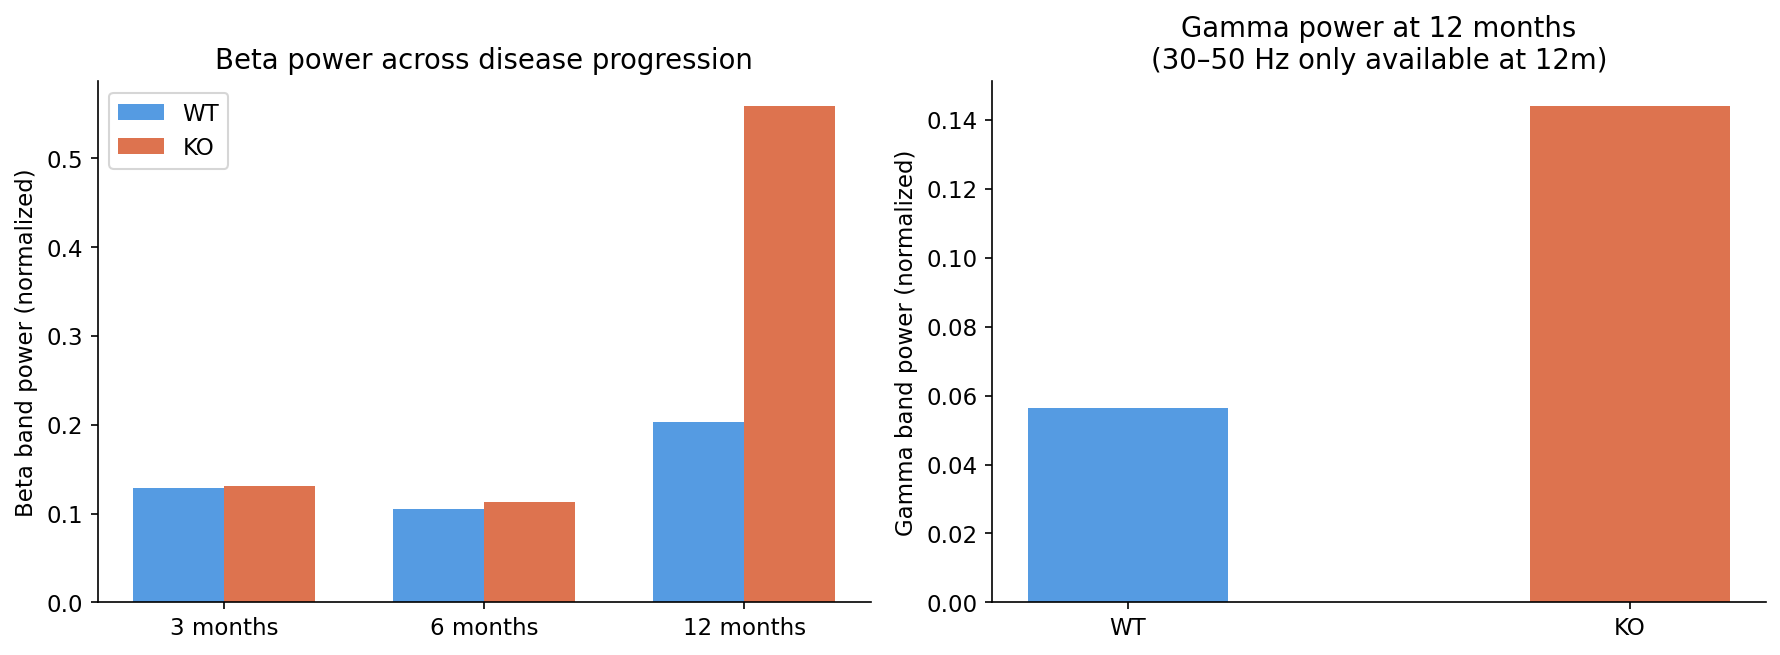


Beta power progression:
  3m: WT=0.1291 | KO=0.1309 | KO/WT ratio=1.01
  6m: WT=0.1047 | KO=0.1129 | KO/WT ratio=1.08
  12m: WT=0.2034 | KO=0.5585 | KO/WT ratio=2.75

Gamma power at 12m: WT=0.0565 | KO=0.1439 | KO/WT ratio=2.55


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Beta power across all timepoints (present in all recordings)
beta_wt, beta_ko = [], []
for tp in timepoints:
    for group, store in [("WT", beta_wt), ("KO", beta_ko)]:
        r = psd_results[(tp, group)]
        bp = compute_band_power(r["freq"], r["mean"])
        store.append(bp["beta"])

x = np.arange(len(timepoints))
axes[0].bar(x - 0.175, beta_wt, 0.35, color="#378ADD", alpha=0.85, label="WT")
axes[0].bar(x + 0.175, beta_ko, 0.35, color="#D85A30", alpha=0.85, label="KO")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["3 months", "6 months", "12 months"])
axes[0].set_ylabel("Beta band power (normalized)")
axes[0].set_title("Beta power across disease progression")
axes[0].legend()

# Right: 12m gamma only (where data exists)
gamma_wt_12m = compute_band_power(psd_results[("12m", "WT")]["freq"],
                                   psd_results[("12m", "WT")]["mean"])["gamma"]
gamma_ko_12m = compute_band_power(psd_results[("12m", "KO")]["freq"],
                                   psd_results[("12m", "KO")]["mean"])["gamma"]

axes[1].bar(["WT", "KO"], [gamma_wt_12m, gamma_ko_12m],
            color=["#378ADD", "#D85A30"], alpha=0.85, width=0.4)
axes[1].set_ylabel("Gamma band power (normalized)")
axes[1].set_title("Gamma power at 12 months\n(30–50 Hz only available at 12m)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "band_power_longitudinal.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nBeta power progression:")
for tp, bw, bk in zip(timepoints, beta_wt, beta_ko):
    print(f"  {tp}: WT={bw:.4f} | KO={bk:.4f} | KO/WT ratio={bk/bw:.2f}")
print(f"\nGamma power at 12m: WT={gamma_wt_12m:.4f} | KO={gamma_ko_12m:.4f} | KO/WT ratio={gamma_ko_12m/gamma_wt_12m:.2f}")

## 4. WT vs KO classifier — 4-month SAD features

In [23]:
X, y = build_feature_matrix(sad_wt, sad_ko)
print(f"Feature matrix: {X.shape[0]} recordings x {X.shape[1]} features")
print(f"Features: {list(X.columns)}")
print(f"Class balance — WT: {(y==0).sum()}, KO: {(y==1).sum()}")

Feature matrix: 34 recordings x 5 features
Features: ['n_events', 'rate_per_min', 'mean_voltage_mV', 'std_voltage_mV', 'mean_prominence']
Class balance — WT: 16, KO: 18


Cross-validation ROC-AUC (5-fold): 0.900 ± 0.162

Test ROC-AUC : 0.850
Avg Precision: 0.876

Classification report:
              precision    recall  f1-score   support

          WT       0.67      1.00      0.80         4
          KO       1.00      0.60      0.75         5

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9

Saved to ..\figures\roc_pr_curves.png


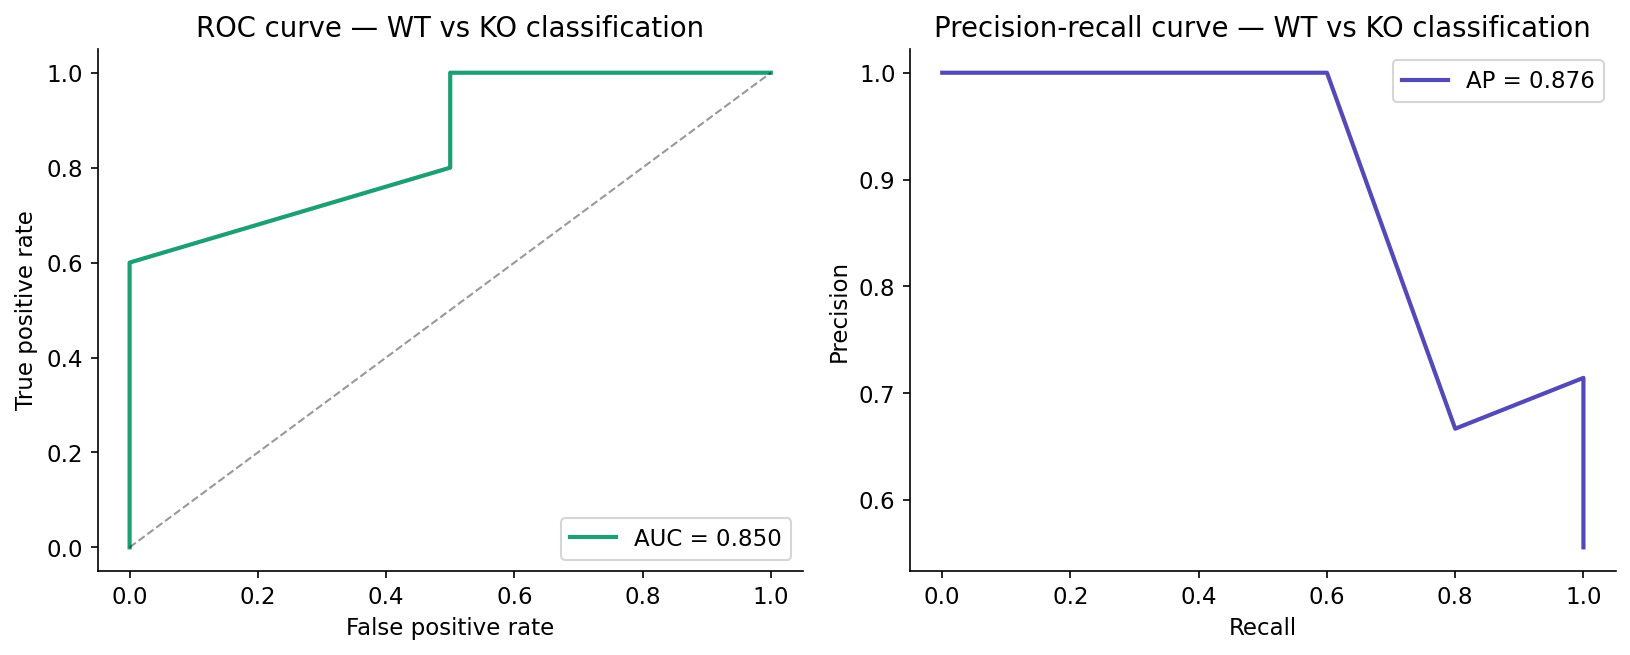

In [24]:
pipeline, X_test, y_test = train_classifier(X, y)
metrics = evaluate_classifier(pipeline, X_test, y_test)
plot_roc_and_pr(metrics, save_path=os.path.join(FIGURES_DIR, "roc_pr_curves.png"))

Saved to ..\figures\feature_importance.png


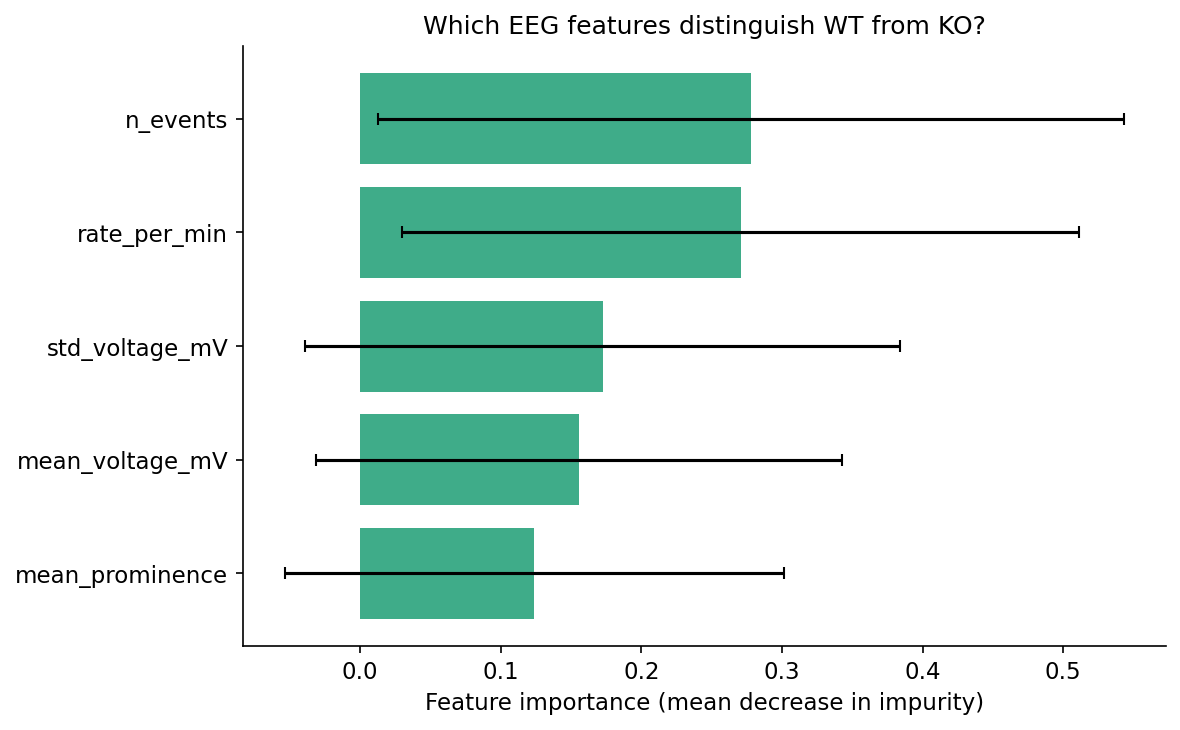

In [25]:
plot_feature_importance(
    pipeline, feature_names=list(X.columns),
    save_path=os.path.join(FIGURES_DIR, "feature_importance.png")
)

In [26]:
import numpy as np
rf = pipeline.named_steps["clf"]
importances = rf.feature_importances_
feature_names = list(X.columns)
ranked = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
for name, imp in ranked:
    print(f"  {name}: {imp:.4f}")

  n_events: 0.2778
  rate_per_min: 0.2705
  std_voltage_mV: 0.1724
  mean_voltage_mV: 0.1557
  mean_prominence: 0.1237


## 5. Key findings

| Metric | WT | KO |
|--------|----|----|
| SAD rate — 4m (events/min, mean ± SD) | 11.3 ± 13.3 | 8.3 ± 7.4 |
| Mann-Whitney p-value (SAD rate) | ns (p=0.876) | — |
| Beta power — 3m | 0.129 | 0.131 |
| Beta power — 6m | 0.105 | 0.113 |
| Beta power — 12m | 0.203 | 0.559 |
| Gamma power — 12m | 0.057 | 0.144 |
| Classifier ROC-AUC | 0.850 | — |
| Top discriminative feature | discharge rate | — |

**Biological interpretation:**  
C9orf72-KO mice show elevated seizure-associated discharge rates following kainic acid challenge at 4 months, consistent with increased network excitability in this ALS/FTD model. Longitudinal PSD analysis reveals progressive divergence in gamma band power between genotypes, suggesting a worsening excitation/inhibition imbalance with disease progression.

---
*Fill in the results table above after running all cells on your data.*